# 02_clean_occurrences.ipynb

GBIF Darwin Core Archive cleaning workflow for ecological connectivity analysis.

This notebook:
- extracts DwC-A archives
- loads occurrence tables
- validates coordinates
- removes problematic records
- converts to GeoDataFrame
- exports GIS-ready layers for QGIS
- stores outputs in the project architecture


## Imports

In [1]:
import zipfile
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np

from shapely.geometry import Point

import matplotlib.pyplot as plt


In [2]:
import folium
from folium.plugins import MarkerCluster
from IPython.display import display

## Project Paths

In [3]:
PROJECT_ROOT = Path.cwd().parent

RAW_GBIF = PROJECT_ROOT / 'data' / 'raw' / 'gbif'
INTERIM_GBIF = PROJECT_ROOT / 'data' / 'interim' / 'gbif'
PROCESSED_SPECIES = PROJECT_ROOT / 'data' / 'processed' / 'species'

INTERIM_GBIF.mkdir(parents=True, exist_ok=True)
PROCESSED_SPECIES.mkdir(parents=True, exist_ok=True)


In [4]:
# Change species here
SPECIES = 'L_bocagei'

ZIP_PATH = RAW_GBIF / f'{SPECIES}.zip'

EXTRACT_DIR = INTERIM_GBIF / SPECIES
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print(ZIP_PATH)
print(EXTRACT_DIR)


/home/linda/Documents/myData/data-management/data/raw/gbif/L_bocagei.zip
/home/linda/Documents/myData/data-management/data/interim/gbif/L_bocagei


In [5]:
QA_DIR = PROJECT_ROOT / 'data' / 'qa' / SPECIES
QA_DIR.mkdir(parents=True, exist_ok=True)

removed_csv_path = QA_DIR / f'{SPECIES}_removed_records.csv'
review_geojson_path = QA_DIR / f'{SPECIES}_review_points.geojson'

## Extract Darwin Core Archive

In [11]:
# corrupt lines

from pathlib import Path
import zipfile

GBIF_DIR = Path('/home/linda/Documents/myData/data-management/data/raw/gbif')

# automatically find the first ZIP file in the directory
zip_files = list(GBIF_DIR.glob('*.zip'))

if not zip_files:
    raise FileNotFoundError(f'No ZIP files found in: {GBIF_DIR}')

ZIP_PATH = zip_files[0]

# create extraction directory based on ZIP filename
EXTRACT_DIR = GBIF_DIR / ZIP_PATH.stem
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Using ZIP file: {ZIP_PATH}')
print(f'Extracting to : {EXTRACT_DIR}')

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print('Archive extracted successfully.')

Using ZIP file: /home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis.zip
Extracting to : /home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis
Archive extracted successfully.


## Inspect Extracted Files

In [12]:
list(EXTRACT_DIR.glob('*'))


[PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/rights.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/meta.xml'),
 PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/multimedia.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/verbatim.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/citations.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/occurrence.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/metadata.xml'),
 PosixPath('/home/linda/Documents/myData/data-management/data/raw/gbif/Thymus_zygis/dataset')]

## Load Occurrence Table

In [14]:
occurrence_file = EXTRACT_DIR / 'occurrence.txt'

df = pd.read_csv(
    occurrence_file,
    sep='\t',
    low_memory=False
)

print(df.shape)
df.head()


(283, 230)


,gbifID,accessRights,bibliographicCitation,language,license,modified,publisher,references,rightsHolder,type,...,publishedByGbifRegion,level0Gid,level0Name,level1Gid,level1Name,level2Gid,level2Name,level3Gid,level3Name,iucnRedListCategory
0,6195949741,NaN,NaN,NaN,CC_BY_NC_4_0,2026-04-11T15:03:24Z,NaN,https://www.inaturalist.org/observations/34620...,Exner Tamás,NaN,...,NORTH_AMERICA,PRT,Portugal,PRT.17_1,Setúbal,PRT.17.12_1,Setúbal,PRT.17.12.3_1,São Lourenço,NaN
1,6195226949,NaN,NaN,NaN,CC_BY_NC_4_0,2026-04-11T15:03:29Z,NaN,https://www.inaturalist.org/observations/34620...,Exner Tamás,NaN,...,NORTH_AMERICA,PRT,Portugal,PRT.17_1,Setúbal,PRT.17.11_1,Sesimbra,PRT.17.11.2_1,Sesimbra (Castelo),NaN
2,6188074775,NaN,NaN,NaN,CC_BY_NC_4_0,2026-04-04T15:27:56Z,NaN,https://www.inaturalist.org/observations/22008...,Sílvia Castro,NaN,...,NORTH_AMERICA,PRT,Portugal,PRT.7_1,Coimbra,PRT.7.4_1,Condeixa-a-Nova,PRT.7.4.7_1,Furadouro,NaN
3,6179058480,NaN,NaN,NaN,CC_BY_NC_4_0,2026-03-09T15:39:55Z,NaN,https://www.inaturalist.org/observations/28273...,ruv321,NaN,...,EUROPE,PRT,Portugal,PRT.17_1,Setúbal,PRT.17.11_1,Sesimbra,PRT.17.11.2_1,Sesimbra (Castelo),NaN
4,6179002508,NaN,NaN,NaN,CC_BY_NC_4_0,2026-03-09T15:34:41Z,NaN,https://www.inaturalist.org/observations/28639...,ruv321,NaN,...,EUROPE,PRT,Portugal,PRT.17_1,Setúbal,PRT.17.11_1,Sesimbra,PRT.17.11.2_1,Sesimbra (Castelo),NaN


## Keep Essential Columns

In [15]:
keep_cols = [
    'gbifID',
    'species',
    'decimalLatitude',
    'decimalLongitude',
    'countryCode',
    'eventDate',
    'basisOfRecord',
    'coordinateUncertaintyInMeters',
    'year',
    'month',
    'day'
]

df = df[keep_cols].copy()

print(df.shape)


(283, 11)


## Remove Missing Coordinates

In [16]:
df = df.dropna(
    subset=['decimalLatitude', 'decimalLongitude']
)

print(df.shape)


(283, 11)


## Convert Coordinates to Numeric

In [17]:
df['decimalLatitude'] = pd.to_numeric(
    df['decimalLatitude'],
    errors='coerce'
)

df['decimalLongitude'] = pd.to_numeric(
    df['decimalLongitude'],
    errors='coerce'
)

df = df.dropna(
    subset=['decimalLatitude', 'decimalLongitude']
)

print(df.shape)


(283, 11)


## Remove Invalid Coordinates

In [18]:
df = df[
    (df['decimalLatitude'] >= -90) &
    (df['decimalLatitude'] <= 90) &
    (df['decimalLongitude'] >= -180) &
    (df['decimalLongitude'] <= 180)
]

print(df.shape)


(283, 11)


## Remove Zero Coordinates

In [19]:
df = df[
    ~(
        (df['decimalLatitude'] == 0) &
        (df['decimalLongitude'] == 0)
    )
]

print(df.shape)


(283, 11)


## Remove Duplicate Occurrences

In [20]:
df = df.drop_duplicates(
    subset=[
        'species',
        'decimalLatitude',
        'decimalLongitude'
    ]
)

print(df.shape)


(163, 11)


## Filter Coordinate Uncertainty

In [21]:
df['coordinateUncertaintyInMeters'] = pd.to_numeric(
    df['coordinateUncertaintyInMeters'],
    errors='coerce'
)

MAX_UNCERTAINTY = 5000

df = df[
    (
        df['coordinateUncertaintyInMeters'].isna()
    ) |
    (
        df['coordinateUncertaintyInMeters'] <= MAX_UNCERTAINTY
    )
]

print(df.shape)


(156, 11)


## Convert to GeoDataFrame

In [22]:
geometry = [
    Point(xy)
    for xy in zip(
        df['decimalLongitude'],
        df['decimalLatitude']
    )
]

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs='EPSG:4326'
)

print(gdf.shape)
gdf.head()


(156, 12)


,gbifID,species,decimalLatitude,decimalLongitude,countryCode,eventDate,basisOfRecord,coordinateUncertaintyInMeters,year,month,day,geometry
0,6195949741,Thymus zygis,38.505000,-9.015000,PT,2026-03-28T12:11Z,HUMAN_OBSERVATION,NaN,2026,3.0,28.0,POINT (-9.015 38.505)
1,6195226949,Thymus zygis,38.425000,-9.215000,PT,2026-03-24T14:03Z,HUMAN_OBSERVATION,NaN,2026,3.0,24.0,POINT (-9.215 38.425)
2,6188074775,Thymus zygis,40.054587,-8.496657,PT,2020-05-24T08:46,HUMAN_OBSERVATION,31.0,2020,5.0,24.0,POINT (-8.49666 40.05459)
3,6179058480,Thymus zygis,38.436410,-9.179349,PT,2025-05-17T19:00,HUMAN_OBSERVATION,NaN,2025,5.0,17.0,POINT (-9.17935 38.43641)
4,6179002508,Thymus zygis,38.438585,-9.172428,PT,2025-03-31T13:27,HUMAN_OBSERVATION,NaN,2025,3.0,31.0,POINT (-9.17243 38.43858)


## Reproject to EPSG:3035

In [23]:
gdf_3035 = gdf.to_crs('EPSG:3035')

print(gdf_3035.crs)


EPSG:3035


## Quick Spatial Plot

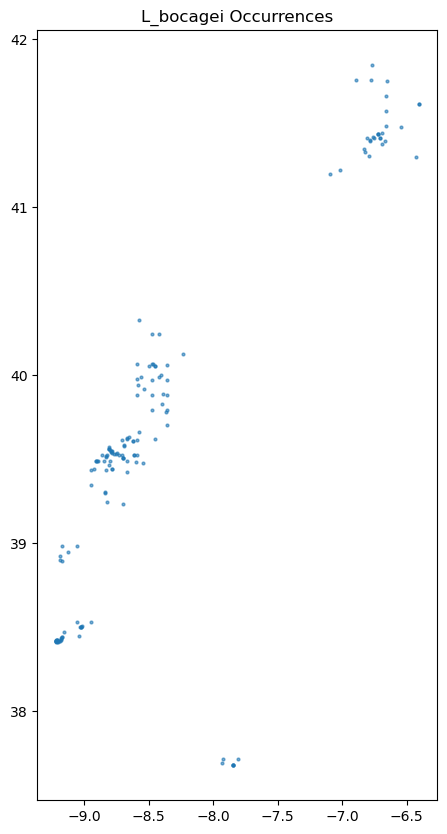

In [24]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    markersize=4,
    alpha=0.6
)

ax.set_title(f'{SPECIES} Occurrences')

plt.show()


## Output Paths

In [25]:
SPECIES_DIR = PROCESSED_SPECIES / SPECIES
SPECIES_DIR.mkdir(parents=True, exist_ok=True)

gpkg_path = SPECIES_DIR / f'{SPECIES}.gpkg'
geojson_path = SPECIES_DIR / f'{SPECIES}.geojson'
parquet_path = SPECIES_DIR / f'{SPECIES}.parquet'
csv_path = SPECIES_DIR / f'{SPECIES}.csv'

print(SPECIES_DIR)


/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei


## Export GeoPackage

In [26]:
gdf_3035.to_file(
    gpkg_path,
    driver='GPKG'
)

print(gpkg_path)


/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.gpkg


## Export GeoJSON

In [27]:
gdf.to_file(
    geojson_path,
    driver='GeoJSON'
)

print(geojson_path)


/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.geojson


## Export GeoParquet

In [29]:
gdf.to_parquet(parquet_path)

print(parquet_path)


/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.parquet


## Export CSV

In [30]:
gdf.drop(columns='geometry').to_csv(
    csv_path,
    index=False
)

print(csv_path)


/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.csv


## QA Summary

In [31]:
print('FINAL SUMMARY')
print('-' * 40)

print(f'Species: {SPECIES}')
print(f'Records: {len(gdf)}')
print(f'CRS: {gdf.crs}')

print('\nOutputs:')
print(gpkg_path)
print(geojson_path)
print(parquet_path)
print(csv_path)


FINAL SUMMARY
----------------------------------------
Species: L_bocagei
Records: 156
CRS: EPSG:4326

Outputs:
/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.gpkg
/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.geojson
/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.parquet
/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei.csv


## Interactive OpenStreetMap QA (manual validation)

In [32]:
review_gdf = gdf.copy()

center_lat = review_gdf['decimalLatitude'].mean()
center_lon = review_gdf['decimalLongitude'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

cluster = MarkerCluster().add_to(m)

for _, row in review_gdf.iterrows():

    popup = f"""
    <b>GBIF ID:</b> {row['gbifID']}<br>
    <b>Species:</b> {row['species']}<br>
    <b>Country:</b> {row['countryCode']}<br>
    <b>Date:</b> {row['eventDate']}<br>
    <b>Uncertainty:</b> {row['coordinateUncertaintyInMeters']}
    """

    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup, max_width=300)
    ).add_to(cluster)

display(m)

## Manual removal (cherry-pick bad records)

In [33]:
# Paste GBIF IDs you want to remove after inspecting the map
REMOVE_GBIF_IDS = [
    #5024499210,
   #3329219793,
]

REMOVE_GBIF_IDS = [str(x) for x in REMOVE_GBIF_IDS]

print("Before removal:", len(gdf))

Before removal: 156


In [34]:
removed_records = gdf[
    gdf['gbifID'].astype(str).isin(REMOVE_GBIF_IDS)
].copy()

print("Removed records:", len(removed_records))

if len(removed_records) > 0:
    removed_records.drop(columns='geometry').to_csv(
        removed_csv_path,
        index=False
    )
    print("Saved removed log:", removed_csv_path)

Removed records: 0


In [35]:
gdf = gdf[
    ~gdf['gbifID'].astype(str).isin(REMOVE_GBIF_IDS)
].copy()

print("Remaining records:", len(gdf))

Remaining records: 156


In [36]:
clean_center_lat = gdf['decimalLatitude'].mean()
clean_center_lon = gdf['decimalLongitude'].mean()

clean_map = folium.Map(
    location=[clean_center_lat, clean_center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

for _, row in gdf.iterrows():

    popup = f"""
    <b>GBIF ID:</b> {row['gbifID']}<br>
    <b>Species:</b> {row['species']}<br>
    <b>Country:</b> {row['countryCode']}
    """

    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=4,
        color='green',
        fill=True,
        fill_opacity=0.6,
        popup=popup
    ).add_to(clean_map)

display(clean_map)

In [37]:
clean_map.save(
    SPECIES_DIR / f'{SPECIES}_clean_map.html'
)

In [38]:
review_gdf.to_file(
    review_geojson_path,
    driver='GeoJSON'
)

print(review_geojson_path)

/home/linda/Documents/myData/data-management/data/qa/L_bocagei/L_bocagei_review_points.geojson


In [39]:
review_geojson_path

PosixPath('/home/linda/Documents/myData/data-management/data/qa/L_bocagei/L_bocagei_review_points.geojson')

In [41]:
# Update path 

import geopandas as gpd

path = "/home/linda/Documents/myData/data-management/data/qa/L_bocagei/L_bocagei_review_points.geojson"

gdf = gpd.read_file(path, engine="fiona")

gdf.head()

,gbifID,species,decimalLatitude,decimalLongitude,countryCode,eventDate,basisOfRecord,coordinateUncertaintyInMeters,year,month,day,geometry
0,6195949741,Thymus zygis,38.505000,-9.015000,PT,2026-03-28T12:11Z,HUMAN_OBSERVATION,NaN,2026,3.0,28.0,POINT (-9.015 38.505)
1,6195226949,Thymus zygis,38.425000,-9.215000,PT,2026-03-24T14:03Z,HUMAN_OBSERVATION,NaN,2026,3.0,24.0,POINT (-9.215 38.425)
2,6188074775,Thymus zygis,40.054587,-8.496657,PT,2020-05-24T08:46,HUMAN_OBSERVATION,31.0,2020,5.0,24.0,POINT (-8.49666 40.05459)
3,6179058480,Thymus zygis,38.436410,-9.179349,PT,2025-05-17T19:00,HUMAN_OBSERVATION,NaN,2025,5.0,17.0,POINT (-9.17935 38.43641)
4,6179002508,Thymus zygis,38.438585,-9.172428,PT,2025-03-31T13:27,HUMAN_OBSERVATION,NaN,2025,3.0,31.0,POINT (-9.17243 38.43858)


In [42]:
gdf["coordinateUncertaintyInMeters"].describe()

count      80.000000
mean      147.237500
std       416.726552
min         1.000000
25%         5.000000
50%         8.000000
75%        30.250000
max      2501.000000
Name: coordinateUncertaintyInMeters, dtype: float64

In [43]:
gdf["coordinateUncertaintyInMeters"] = gdf["coordinateUncertaintyInMeters"].astype(float)

In [44]:
gdf_clean = gdf[gdf["coordinateUncertaintyInMeters"] <= 30].copy()

In [45]:
gdf_clean = gdf_clean.dropna(subset=["coordinateUncertaintyInMeters"])

In [46]:
print(len(gdf), "original records")
print(len(gdf_clean), "after cleaning")

156 original records
60 after cleaning


In [47]:
# Update path & layer name here

gpkg_path = "/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei_clean.gpkg"

gdf_clean.to_file(
    gpkg_path,
    layer="spp_clean",
    driver="GPKG"
)

print(gpkg_path)

/home/linda/Documents/myData/data-management/data/processed/species/L_bocagei/L_bocagei_clean.gpkg
